**8. IBM HR Analytics (Employee Attrition)**  
- **Dataset:** IBM HR Analytics Employee Attrition (https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)  
- **Guiding Question:** What are the primary drivers of employee turnover, and how do factors like distance from home, salary, and job satisfaction interact?

In [18]:
# Cell 1: Import Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df = pd.read_csv('HR-Employee-Attrition.csv')

# Set aesthetic style for all plots
sns.set_theme(style="whitegrid")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [39]:
# Select columns by their index positions (0, 1, 5, 11, 16, 18)
selected_df = df.iloc[:, [0, 1, 5, 11, 16, 18]]

# Display the first 5 rows
print(selected_df.head(10))

   Age Attrition  DistanceFromHome  Gender  JobSatisfaction  MonthlyIncome
0   41       Yes                 1  Female                4           5993
1   49        No                 8    Male                2           5130
2   37       Yes                 2    Male                3           2090
3   33        No                 3  Female                3           2909
4   27        No                 2    Male                2           3468
5   32        No                 2    Male                4           3068
6   59        No                 3  Female                1           2670
7   30        No                24    Male                3           2693
8   38        No                23    Male                3           9526
9   36        No                27    Male                3           5237


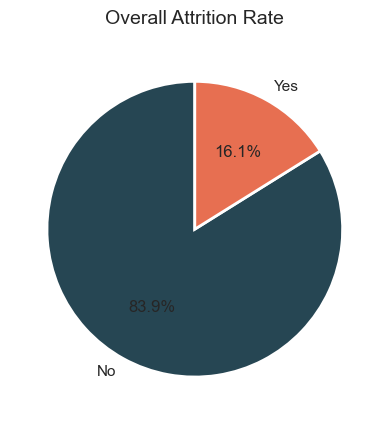

In [22]:
palette = {"Yes": "#E76F51", "No": "#264653"}

# Calculate distribution
attrition_counts = df['Attrition'].value_counts()

# Plot pie chart
plt.pie(
    attrition_counts, 
    labels=attrition_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=[palette['No'], palette['Yes']],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Overall Attrition Rate', fontsize=14, pad=15)
plt.show()

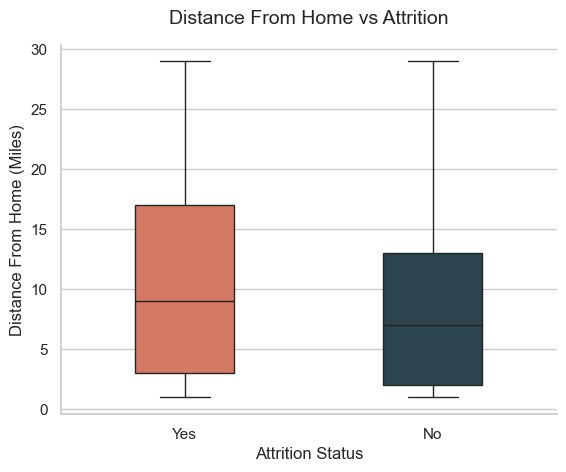

In [20]:
# Added hue='Attrition' and legend=False to satisfy the warning cleanly
sns.boxplot(
    x='Attrition', 
    y='DistanceFromHome', 
    hue='Attrition',
    data=df, 
    palette={"Yes": "#E76F51", "No": "#264653"}, 
    width=0.4,
    showfliers=False,
    legend=False
)

plt.title('Distance From Home vs Attrition', fontsize=14, pad=15)
plt.xlabel('Attrition Status', fontsize=12)
plt.ylabel('Distance From Home (Miles)', fontsize=12)

# Remove unnecessary border lines
sns.despine()
plt.show()

**Conclusion:** Employees who resign (Attrition: Yes) generally have a longer commute. The middle 50% of people who left live between 3 and 17 miles away, whereas the middle 50% of people who stayed live closer, between 2 and 13 miles away. This suggests that a longer distance from home is a contributing driver to employee turnover.

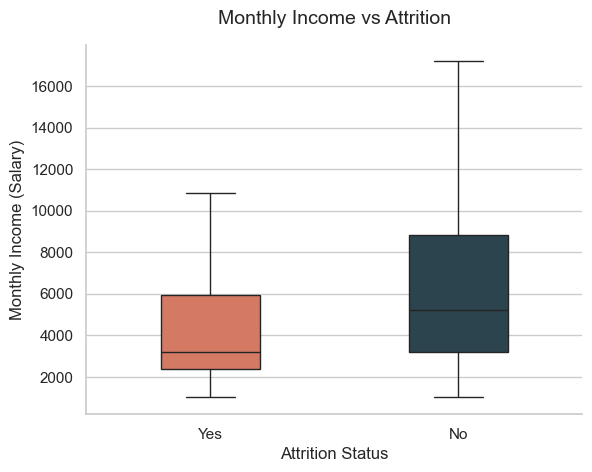

In [21]:
# Added hue='Attrition' and legend=False to satisfy the warning cleanly
sns.boxplot(
    x='Attrition', 
    y='MonthlyIncome', 
    hue='Attrition',
    data=df, 
    palette={"Yes": "#E76F51", "No": "#264653"}, 
    width=0.4,
    showfliers=False,
    legend=False
)

plt.title('Monthly Income vs Attrition', fontsize=14, pad=15)
plt.xlabel('Attrition Status', fontsize=12)
plt.ylabel('Monthly Income (Salary)', fontsize=12)

# Remove unnecessary border lines
sns.despine()
plt.show()

**Conclusion:** Low monthly income is a major primary driver of employee turnover. The median salary of employees who resign (3,200) is drastically lower than those who stay (5,200). Furthermore, the vast majority of employees who left made under 6,000, while higher earners (above 11,000) show almost zero attrition.

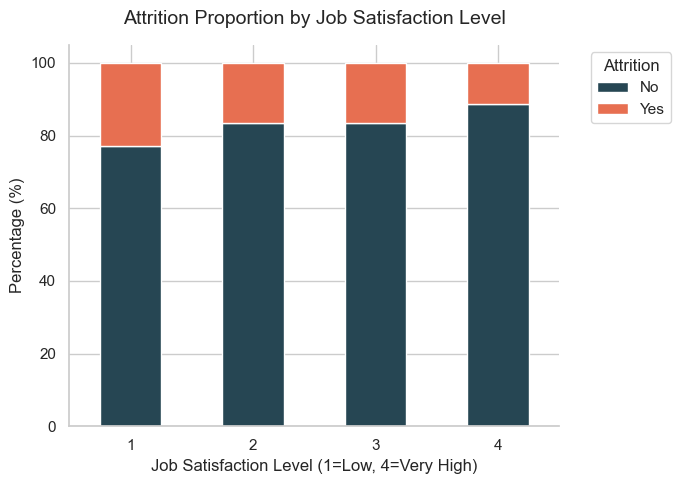

In [14]:
plt.figure(figsize=(7, 5))

# 1. Create a cross-tabulation table of percentages
satisfaction_pct = pd.crosstab(
    df['JobSatisfaction'], 
    df['Attrition'], 
    normalize='index'
) * 100

# 2. Plot the 100% stacked horizontal or vertical bar chart
palette = {"Yes": "#E76F51", "No": "#264653"}
satisfaction_pct.plot(
    kind='bar', 
    stacked=True, 
    color=[palette['No'], palette['Yes']], 
    ax=plt.gca(),
    width=0.5
)

# 3. Clean and polish the labels
plt.title('Attrition Proportion by Job Satisfaction Level', fontsize=14, pad=15)
plt.xlabel('Job Satisfaction Level (1=Low, 4=Very High)', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0) # Keeps the x-axis numbers upright

# Place the legend cleanly outside the plot area
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

**Conclusion:** Job satisfaction has a clear, inverse relationship with employee turnover. As job satisfaction increases from Low (1) to Very High (4), the resignation rate drops by more than half (from roughly 23% down to 11%). This confirms that lower job satisfaction is a key driver of attrition, while high job satisfaction acts as a strong retention factor.

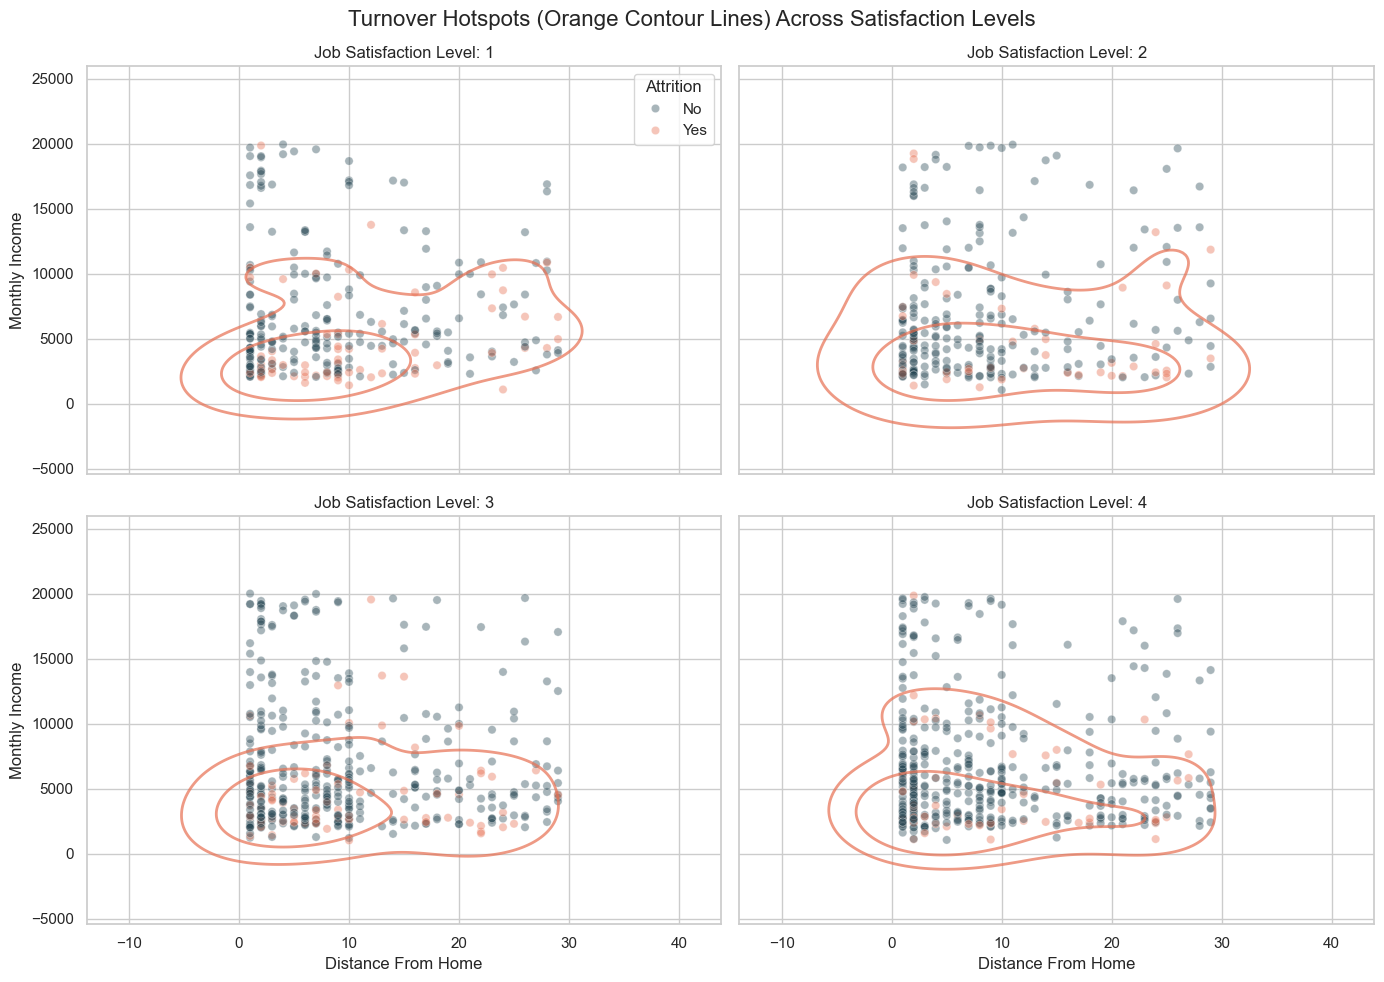

In [36]:
# Create a 2x2 grid manually to overlay scatter and density curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Filter for just the employees who left to isolate their density curve
attrition_yes_df = df[df["Attrition"] == "Yes"]

for idx, satisfaction in enumerate([1, 2, 3, 4]):
    ax = axes[idx]

    # Subset data for the specific Job Satisfaction level
    sub_df = df[df["JobSatisfaction"] == satisfaction]
    sub_yes = attrition_yes_df[attrition_yes_df["JobSatisfaction"] == satisfaction]

    # 1. Plot the background dots
    sns.scatterplot(
        data=sub_df,
        x="DistanceFromHome",
        y="MonthlyIncome",
        hue="Attrition",
        palette={"Yes": "#E76F51", "No": "#264653"},
        alpha=0.4,
        ax=ax,
        legend=(idx == 0),  # Show legend only on the first plot
    )

    # 2. Draw the "Curve/Boundary" line for the orange dots (Turnover Hotspot)
    if not sub_yes.empty:
        sns.kdeplot(
            data=sub_yes,
            x="DistanceFromHome",
            y="MonthlyIncome",
            color="#E76F51",
            levels=3,  # Draws 3 concentric boundary lines
            thresh=0.2,  # Cuts off low-density noise
            alpha=0.7,
            linewidths=2,
            ax=ax,
        )

    ax.set_title(f"Job Satisfaction Level: {satisfaction}")
    ax.set_xlabel("Distance From Home")
    ax.set_ylabel("Monthly Income")

plt.suptitle(
    "Turnover Hotspots (Orange Contour Lines) Across Satisfaction Levels",
    y=0.98,
    fontsize=16,
)
plt.tight_layout()
plt.savefig("attrition_hotspots.png", bbox_inches="tight")
plt.show()

**Conclusion:** The primary drivers of employee turnover are not isolated factors; instead, turnover is a compounding crisis driven by a deadly combination of low compensation, low job satisfaction, and long commute distances.
While the company's baseline attrition rate sits at a moderate 16.1%, the data proves that turnover spikes catastrophically—reaching between 31.2% and 50.0%—within a highly specific, high-risk pocket of the workforce.

In [34]:
# 1. Create meaningful bins for Distance and Income
df["Distance_Group"] = pd.cut(
    df["DistanceFromHome"],
    bins=[0, 5, 12, 30],
    labels=["Near (0-5mi)", "Moderate (6-12mi)", "Far (13-30mi)"],
)

df["Income_Group"] = pd.cut(
    df["MonthlyIncome"],
    bins=[0, 4000, 8000, 25000],
    labels=["Low (<4k)", "Medium (4k-8k)", "High (>8k)"],
)

# 2. Group the data to calculate the exact interaction matrix
interaction_matrix = (
    df.groupby(
        ["JobSatisfaction", "Income_Group", "Distance_Group"], observed=False
    )["Attrition"]
    .agg(
        Total_Employees="count",
        Turnover_Count=lambda x: (x == "Yes").sum(),
        Turnover_Rate=lambda x: round((x == "Yes").mean() * 100, 1),
    )
    .reset_index()
)

# 3. Filter out groups with very small sample sizes (e.g., fewer than 10 employees)
# This prevents 1 single person out of 2 from showing up as an artificial 50% or 0% rate.
filtered_matrix = interaction_matrix[
    interaction_matrix["Total_Employees"] >= 10
]

# 4. Get the Top 4 Highest and Bottom 4 Lowest turnover rates
highest_four = filtered_matrix.sort_values(
    by="Turnover_Rate", ascending=False
).head(4)
lowest_four = filtered_matrix.sort_values(
    by="Turnover_Rate", ascending=True
).head(4)

# 5. Print results cleanly
print("=" * 40)
print("   TOP 4 HIGHEST TURNOVER RISK ZONES")
print("=" * 40)
print(highest_four.to_string(index=False))

print("\n" + "=" * 40)
print("   BOTTOM 4 LOWEST TURNOVER RISK ZONES")
print("=" * 40)
print(lowest_four.to_string(index=False))

   TOP 4 HIGHEST TURNOVER RISK ZONES
 JobSatisfaction Income_Group    Distance_Group  Total_Employees  Turnover_Count  Turnover_Rate
               1    Low (<4k) Moderate (6-12mi)               32              16           50.0
               2    Low (<4k)     Far (13-30mi)               30              13           43.3
               1    Low (<4k)     Far (13-30mi)               20               7           35.0
               1    Low (<4k)      Near (0-5mi)               48              15           31.2

   BOTTOM 4 LOWEST TURNOVER RISK ZONES
 JobSatisfaction   Income_Group    Distance_Group  Total_Employees  Turnover_Count  Turnover_Rate
               2     High (>8k) Moderate (6-12mi)               22               0            0.0
               3     High (>8k)      Near (0-5mi)               47               1            2.1
               1 Medium (4k-8k)      Near (0-5mi)               37               1            2.7
               4 Medium (4k-8k) Moderate (6-12mi)  